In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../Data/retail_sales_15000.csv")

df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Type,Customer_Segment,Region,State,City,Category,Product_Name,...,Shipping_Cost,Payment_Mode,Sales_Channel,Order_Status,Delivery_Days,Product_Rating,Month,Month_Name,Quarter,Festival_Season
0,ORD006634,2024-06-17,CUST00960,New,Consumer,East,West Bengal,Kolkata,Grocery,Cooking Oil,...,56.48,Credit Card,Online,Delivered,9,4.3,6,June,2,Regular
1,ORD003766,2024-06-17,CUST01606,New,Home Office,North,Delhi,Dwarka,Home,Sofa,...,5140.29,Credit Card,Online,Delivered,1,4.5,6,June,2,Regular
2,ORD002888,2024-06-17,CUST00107,Returning,Consumer,South,Karnataka,Mysore,Grocery,Sugar,...,27.17,UPI,Offline,Delivered,7,3.8,6,June,2,Regular
3,ORD004156,2024-06-17,CUST02156,Returning,Consumer,West,Rajasthan,Jodhpur,Electronics,Keyboard,...,170.95,Credit Card,Online,Delivered,4,4.9,6,June,2,Regular
4,ORD008743,2024-06-17,CUST00250,Returning,Consumer,West,Maharashtra,Mumbai,Grocery,Rice,...,92.71,UPI,Offline,Delivered,3,4.1,6,June,2,Regular


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 15000
Columns: 26


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          15000 non-null  object 
 1   Order_Date        15000 non-null  object 
 2   Customer_ID       15000 non-null  object 
 3   Customer_Type     15000 non-null  object 
 4   Customer_Segment  15000 non-null  object 
 5   Region            15000 non-null  object 
 6   State             15000 non-null  object 
 7   City              15000 non-null  object 
 8   Category          15000 non-null  object 
 9   Product_Name      15000 non-null  object 
 10  Quantity          15000 non-null  int64  
 11  Unit_Price        15000 non-null  int64  
 12  Discount_Percent  15000 non-null  int64  
 13  Sales             15000 non-null  float64
 14  Cost              15000 non-null  float64
 15  Profit            15000 non-null  float64
 16  Shipping_Cost     15000 non-null  float6

In [5]:
df.isnull().sum()

Order_ID            0
Order_Date          0
Customer_ID         0
Customer_Type       0
Customer_Segment    0
Region              0
State               0
City                0
Category            0
Product_Name        0
Quantity            0
Unit_Price          0
Discount_Percent    0
Sales               0
Cost                0
Profit              0
Shipping_Cost       0
Payment_Mode        0
Sales_Channel       0
Order_Status        0
Delivery_Days       0
Product_Rating      0
Month               0
Month_Name          0
Quarter             0
Festival_Season     0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

## Executive KPI Analysis

In [7]:
#Total Revenue
total_revenue = df["Sales"].sum()
print(f"₹{total_revenue:,.2f}")

₹488,031,607.47


In [8]:
#Total Profit
total_profit = df["Profit"].sum()
print(f"₹{total_profit:,.2f}")

₹101,380,426.86


In [9]:
#Total Orders
total_orders = df["Order_ID"].nunique()
print(total_orders)

15000


In [10]:
#Unique Customers
unique_customers = df["Customer_ID"].nunique()
print(unique_customers)

2496


In [11]:
#Profit Margin
profit_margin = (
    total_profit /
    total_revenue
) * 100

print(round(profit_margin,2))

20.77


In [12]:
#Average Order Value
aov = (
    total_revenue /
    total_orders
)

print(round(aov,2))

32535.44


## Monthly Revenue Trend

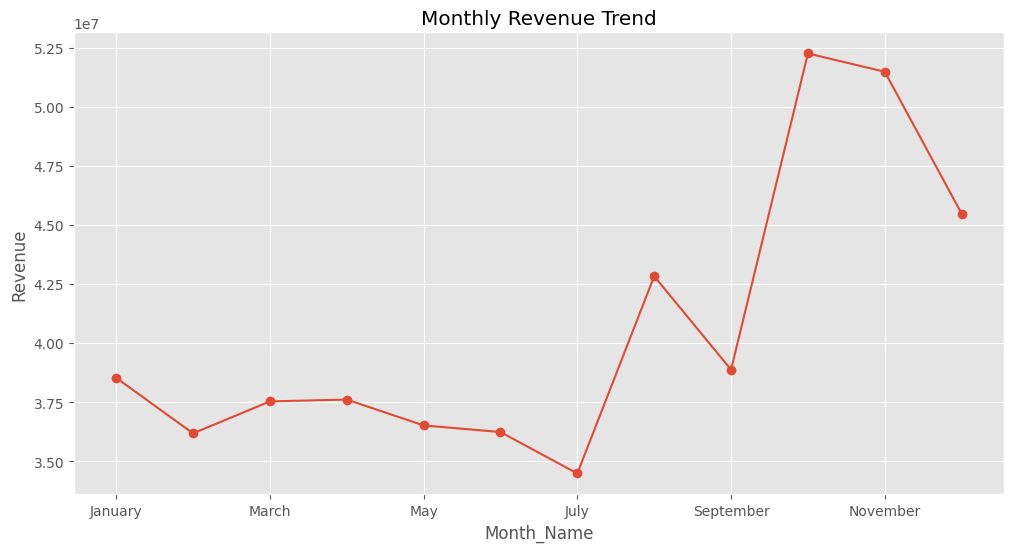

In [13]:
month_order = [
    "January","February","March",
    "April","May","June",
    "July","August","September",
    "October","November","December"
]

monthly_sales = df.groupby(
    "Month_Name"
)["Sales"].sum().reindex(month_order)

plt.figure(figsize=(12,6))

monthly_sales.plot(
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()

#Insight
#Look for Diwali and Year-End spikes

## Revenue by Category

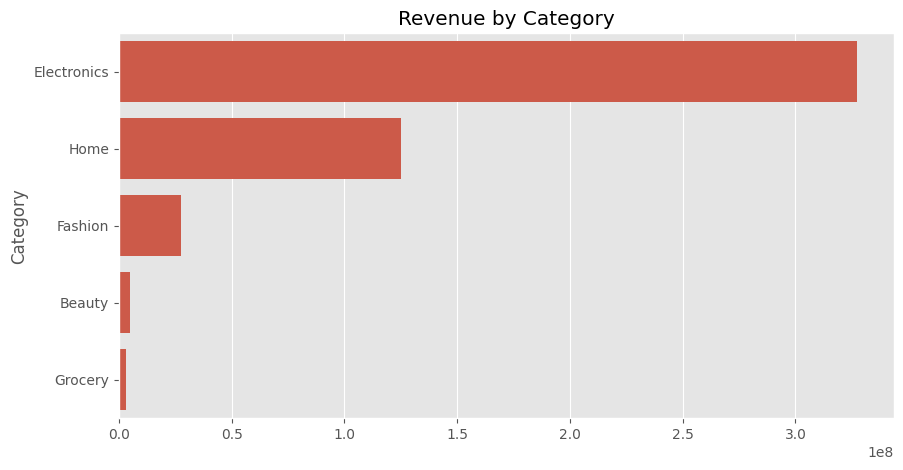

In [14]:
category_sales = (
    df.groupby("Category")
    ["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=category_sales.values,
    y=category_sales.index
)

plt.title("Revenue by Category")
plt.show()

#Business Question: Which category drives the business?

## Profit by Category

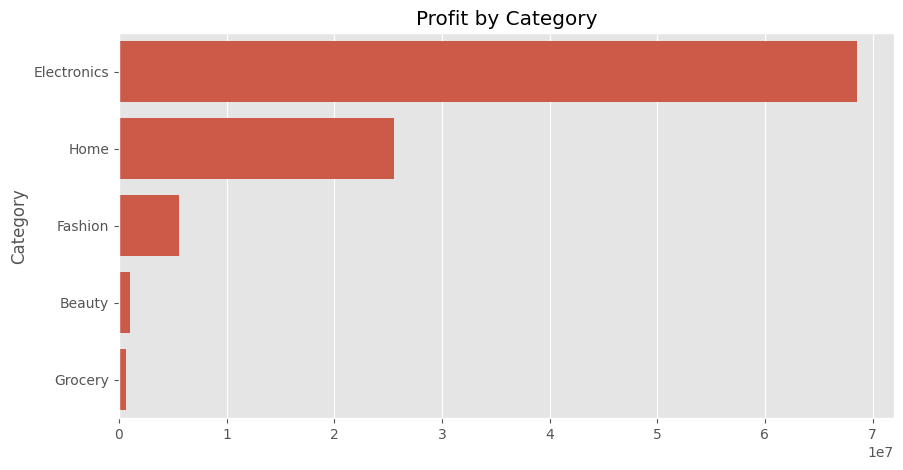

In [15]:
category_profit = (
    df.groupby("Category")
    ["Profit"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=category_profit.values,
    y=category_profit.index
)

plt.title("Profit by Category")
plt.show()

## Top 10 Products

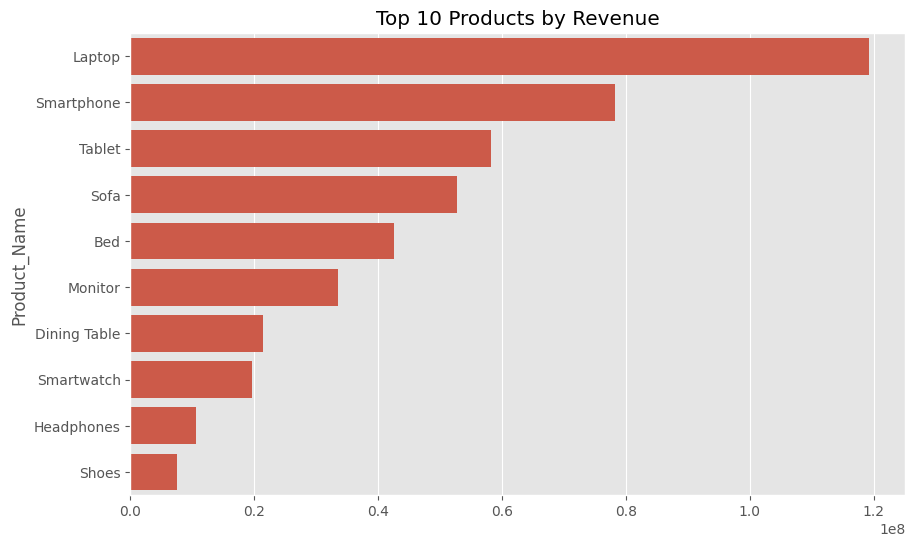

In [16]:
top_products = (
    df.groupby("Product_Name")
    ["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products by Revenue")
plt.show()

## Regional Performance

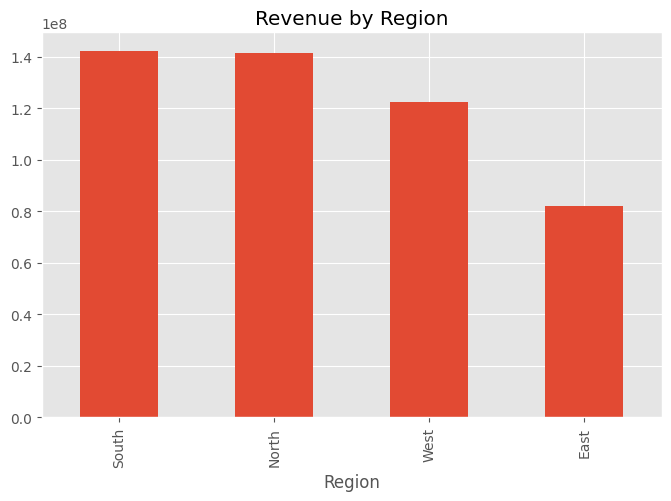

In [17]:
region_sales = (
    df.groupby("Region")
    ["Sales"]
    .sum()
    .sort_values(ascending=False)
)

region_sales.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Revenue by Region")
plt.show()

## State Analysis   

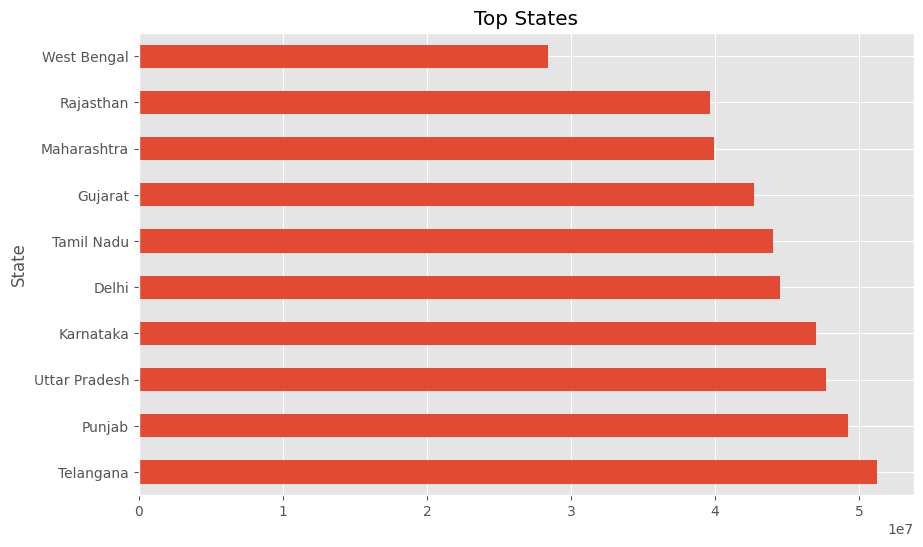

In [18]:
top_states = (
    df.groupby("State")
    ["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_states.plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top States")
plt.show()

## Customer Segment Analysis

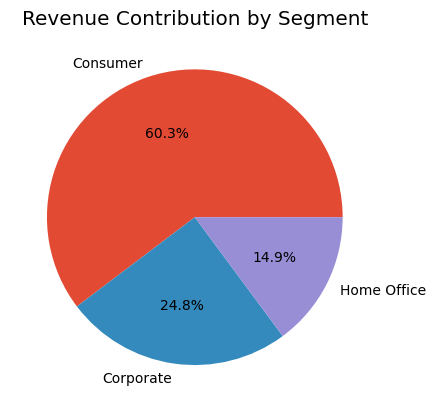

In [19]:
segment_sales = (
    df.groupby("Customer_Segment")
    ["Sales"]
    .sum()
)

segment_sales.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Revenue Contribution by Segment")
plt.ylabel("")
plt.show()

## Sales Channel Analysis

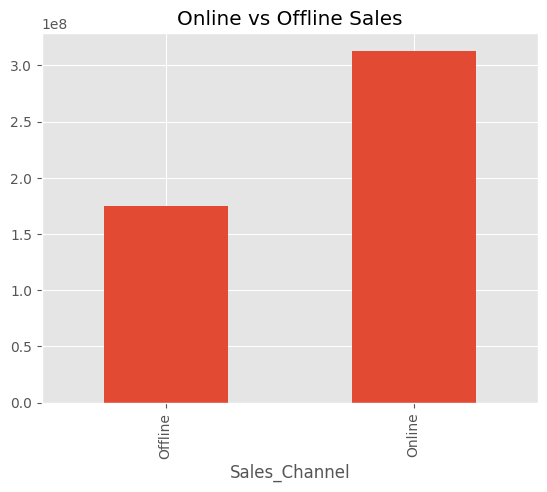

In [20]:
channel_sales = (
    df.groupby("Sales_Channel")
    ["Sales"]
    .sum()
)

channel_sales.plot(
    kind="bar"
)

plt.title("Online vs Offline Sales")
plt.show()

## Payment Mode Analysis

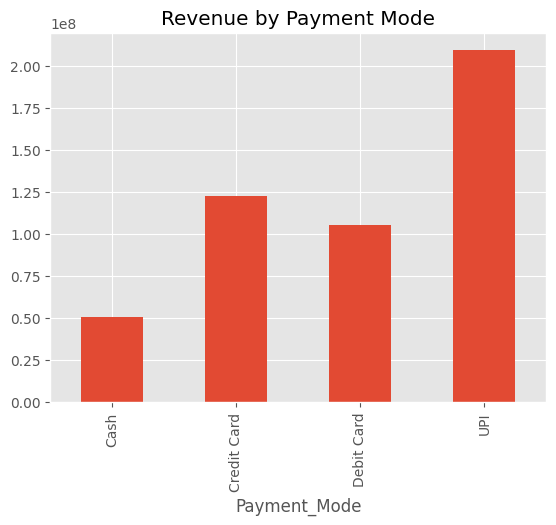

In [21]:
payment_sales = (
    df.groupby("Payment_Mode")
    ["Sales"]
    .sum()
)

payment_sales.plot(
    kind="bar"
)

plt.title("Revenue by Payment Mode")
plt.show()

## Discount Impact Analysis

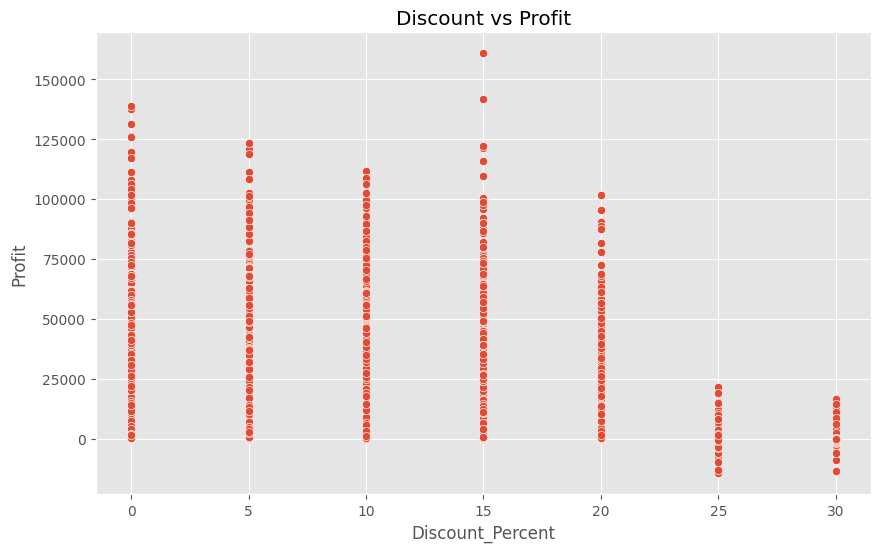

In [22]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df["Discount_Percent"],
    y=df["Profit"]
)

plt.title(
    "Discount vs Profit"
)

plt.show()
#Business Insight: Determine whether higher discounts reduce profitability.

## Return Analysis

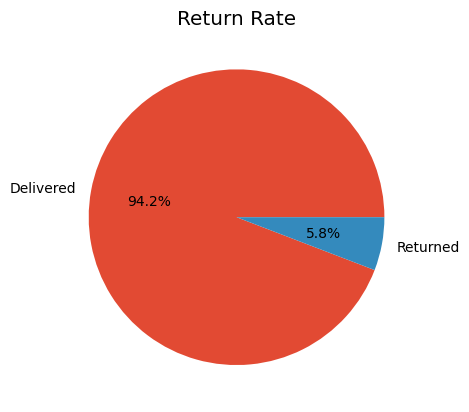

In [23]:
returns = (
    df["Order_Status"]
    .value_counts()
)

returns.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Return Rate")
plt.ylabel("")
plt.show()

## Product Rating Analysis

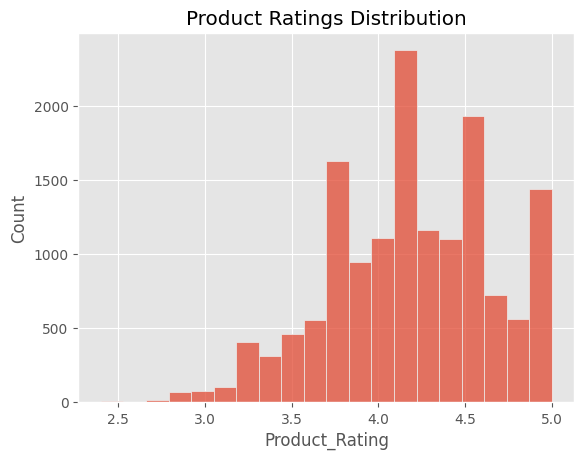

In [24]:
sns.histplot(
    df["Product_Rating"],
    bins=20
)

plt.title("Product Ratings Distribution")
plt.show()

## Delivery Performance

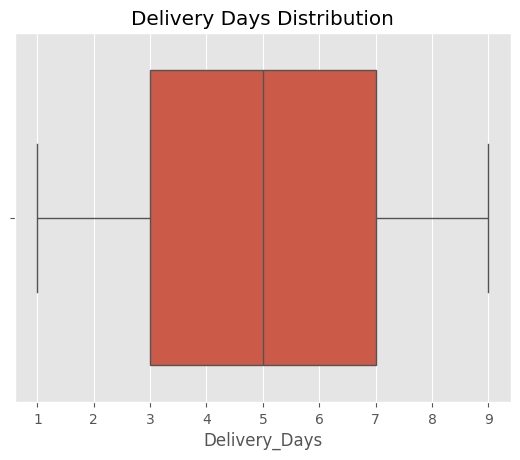

In [25]:
sns.boxplot(
    x=df["Delivery_Days"]
)

plt.title(
    "Delivery Days Distribution"
)

plt.show()

## Pareto Analysis (80/20 Rule)

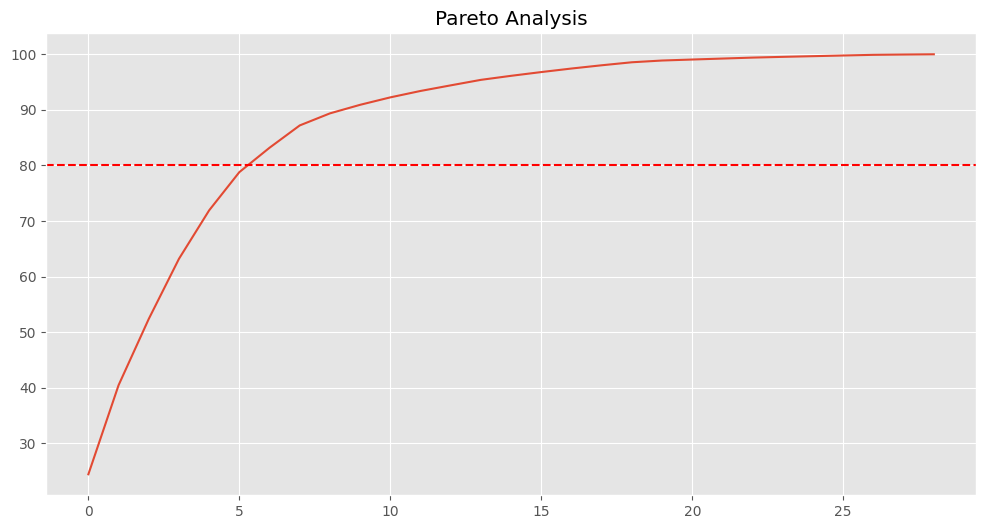

In [26]:
product_sales = (
    df.groupby("Product_Name")
    ["Sales"]
    .sum()
    .sort_values(ascending=False)
)

pareto = product_sales.reset_index()

pareto["CumPct"] = (
    pareto["Sales"]
    .cumsum()
    /
    pareto["Sales"].sum()
) * 100

pareto.head()

#Visualization:

plt.figure(figsize=(12,6))

plt.plot(
    pareto["CumPct"]
)

plt.axhline(
    y=80,
    color="red",
    linestyle="--"
)

plt.title("Pareto Analysis")
plt.show()

## Customer Lifetime Value

In [27]:
clv = (
    df.groupby("Customer_ID")
    ["Sales"]
    .sum()
)

clv.describe()

#Top customers:

clv.sort_values(
    ascending=False
).head(10)

Customer_ID
CUST01580    1356720.00
CUST02081    1337320.73
CUST00577    1128239.70
CUST02066    1052777.04
CUST01820    1002239.00
CUST01997     988212.50
CUST01879     971174.60
CUST02308     953813.71
CUST02405     938345.02
CUST01596     919326.20
Name: Sales, dtype: float64

# Output Files for Power BI

In [28]:
category_sales.to_csv(
    "category_sales.csv"
)

region_sales.to_csv(
    "region_sales.csv"
)

top_products.to_csv(
    "top_products.csv"
)

monthly_sales.to_csv(
    "monthly_sales.csv"
)

In [29]:
# ==========================
# BUSINESS INSIGHTS SUMMARY
# ==========================

top_category = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(top_category)

top_region = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(top_region)

return_rate = (
    (df["Order_Status"] == "Returned").mean()
) * 100

print(f"Return Rate: {return_rate:.2f}%")


Category
Electronics    3.273003e+08
Home           1.252533e+08
Fashion        2.735395e+07
Beauty         4.972853e+06
Grocery        3.151273e+06
Name: Sales, dtype: float64
Region
South    1.422962e+08
North    1.414792e+08
West     1.223211e+08
East     8.193513e+07
Name: Sales, dtype: float64
Return Rate: 5.82%


### Key Findings

- Total Revenue: ₹488.03M
- Total Profit: ₹101.38M
- Profit Margin: 20.77%
- Electronics contributed 67% of total revenue.
- Laptop was the highest revenue-generating product (₹119M).
- South and North regions generated the highest revenue.
- Consumer segment contributed 60.31% of total sales.
- Return rate remained low at 5.82%.

---

### Business Insights

#### 1. Monthly Revenue Trend

Revenue remained relatively stable during the first half of the year, ranging between ₹34M and ₹39M. A significant increase was observed from August onward, with revenue peaking at approximately ₹52M in October and remaining above ₹50M in November. This indicates strong seasonal demand during the festive and holiday period, contributing substantially to annual sales performance.

#### 2. Product Performance Analysis

Laptop emerged as the highest-performing product, generating approximately ₹119M in revenue and ₹25M in profit. Smartphones ranked second with ₹78M revenue and ₹16M profit. These findings indicate that premium electronic products are the primary drivers of business growth and profitability.

#### 3. Category-Wise Revenue Analysis

Electronics dominated all product categories, contributing approximately ₹327M (67.07%) of total revenue. Home products contributed around ₹125M (25.66%), while Fashion, Beauty, and Grocery collectively represented less than 10% of total sales. This highlights a heavy dependence on the Electronics category.

#### 4. Regional Performance Analysis

The South region generated the highest revenue of approximately ₹142M, followed closely by the North region with ₹141M. The West region contributed ₹122M, while the East region generated ₹82M. These results indicate strong market penetration in South and North India and significant growth opportunities in the East region.

#### 5. State-Level Performance

Telangana emerged as the top-performing state with revenue exceeding ₹51M, followed by Punjab and Uttar Pradesh. These states consistently contributed high sales volumes and profits, making them strategically important markets for future expansion and promotional campaigns.

#### 6. Customer Segment Analysis

Consumer customers accounted for 60.31% of total revenue, generating approximately ₹294.35M. Corporate customers contributed 24.82% (₹121.14M), while Home Office customers generated 14.86% (₹72.54M). This indicates that individual consumers represent the largest revenue-generating customer segment.

#### 7. Order Status Analysis

Approximately 94.18% of orders were successfully delivered, while only 5.82% were returned. The low return rate reflects efficient logistics operations and satisfactory product quality, contributing positively to customer satisfaction and profitability.

#### 8. Product Ratings Analysis

The average product rating across all products was 4.19 out of 5, indicating generally positive customer feedback. Consistently high ratings suggest strong product quality and customer satisfaction levels.

#### 9. Discount Analysis

The average discount percentage was 11.16%, which appears sufficient to drive sales without significantly affecting profitability. This demonstrates an effective pricing and promotional strategy.

---

### Recommendations

1. Increase investment in Electronics products, particularly Laptops and Smartphones, as they generate the highest revenue and profit.
2. Expand marketing campaigns in the East region to improve regional sales balance.
3. Develop targeted promotional offers for Corporate and Home Office segments to diversify revenue sources.
4. Leverage festive seasons through inventory planning and marketing campaigns to maximize seasonal demand.
5. Maintain current delivery performance and return management practices to preserve customer satisfaction.
6. Explore growth opportunities in underperforming categories such as Beauty and Grocery to reduce dependence on Electronics.

---

### Conclusion

RetailMax demonstrates strong profitability, with Electronics products driving the majority of revenue and profit. Seasonal demand during Q4 significantly boosts sales performance. Future growth opportunities exist in the East region, Corporate customer segment, and low-performing categories.

---
